# Phase 1: Data Ingestion & Cleaning
## Predicting Hardware End-of-Life

This notebook performs:
1. Ingestion of Dataset 1 (IoT Failure) and Dataset 4 (AI4I Predictive Maintenance).
2. Standardization of column names to the research schema: `Device_ID`, `Thermal_Log`, `Uptime_Cycles`, `Workload_Ratio`, `Failure_Label`.
3. Handling of missing log entries.
4. Baseline Exploratory Data Analysis (EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
plt.style.use('ggplot')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11, 
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 
                     'figure.dpi': 300, 'savefig.dpi': 300})


In [2]:
# Load Dataset 1
df1 = pd.read_csv('../data/raw/dataset1_iot_failure.csv')
print("Dataset 1 Shape:", df1.shape)
print(df1.head())


Dataset 1 Shape: (3000, 11)
   Device_ID  CPU_Usage (%)  Memory_Usage (%)  Battery_Level (%)  \
0       1001      59.934283         21.382887          42.147966   
1       1002      47.234714         37.094225          54.226729   
2       1003      62.953771         43.795917          46.448495   
3       1004      80.460597         78.315315          56.300105   
4       1005      45.316933         58.348297          64.646242   

   Network_Latency (ms)  Packet_Loss (%)  Temperature (°C)  Uptime (hrs)  \
0            138.270108         1.322370         38.565768    116.091760   
1            153.670635         0.000000         39.673441     60.932115   
2            124.934496         0.270543         40.642949    134.567819   
3              2.875115         0.470838         49.468615     70.481915   
4             92.228878         0.511136         32.527827    137.477752   

   Workload_Intensity  Error_Count  Failure_Type  
0                   2            5             2  
1   

In [3]:
# Standardize Dataset 1 columns
# Current columns: ['Device_ID', 'CPU_Usage (%)', 'Memory_Usage (%)', 'Battery_Level (%)',
# 'Network_Latency (ms)', 'Packet_Loss (%)', 'Temperature (°C)', 'Uptime (hrs)', 
# 'Workload_Intensity', 'Error_Count', 'Failure_Type']

df1_clean = pd.DataFrame()
df1_clean['Device_ID'] = df1['Device_ID']
df1_clean['Thermal_Log'] = df1['Temperature (°C)']
df1_clean['Uptime_Cycles'] = df1['Uptime (hrs)']
# Engineer Workload_Ratio from CPU and Memory (average as a simple proxy)
df1_clean['Workload_Ratio'] = (df1['CPU_Usage (%)'] + df1['Memory_Usage (%)']) / 2.0
df1_clean['Failure_Label'] = df1['Failure_Type']

# Map Failure_Label to research failure modes for descriptive analysis
# 0: Healthy, 1: Thermal Overheat, 2: Memory Corruption, 3: Hardware Exhaustion (assumption based on dataset)
failure_map = {0: 'Healthy', 1: 'Thermal_Overheat', 2: 'Memory_Corruption', 3: 'Hardware_Exhaustion'}
df1_clean['Failure_Mode'] = df1_clean['Failure_Label'].map(failure_map).fillna('Unknown')

print(df1_clean.head())


   Device_ID  Thermal_Log  Uptime_Cycles  Workload_Ratio  Failure_Label  \
0       1001    38.565768     116.091760       40.658585              2   
1       1002    39.673441      60.932115       42.164469              3   
2       1003    40.642949     134.567819       53.374844              0   
3       1004    49.468615      70.481915       79.387956              0   
4       1005    32.527827     137.477752       51.832615              0   

          Failure_Mode  
0    Memory_Corruption  
1  Hardware_Exhaustion  
2              Healthy  
3              Healthy  
4              Healthy  


In [4]:
# Load Dataset 4
df4 = pd.read_csv('../data/raw/dataset4_ai4i.csv')
print("Dataset 4 Shape:", df4.shape)
print(df4.head())


Dataset 4 Shape: (10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1  

In [5]:
# Standardize Dataset 4 columns
# Current columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]',
# 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
# 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df4_clean = pd.DataFrame()
df4_clean['Device_ID'] = df4['UDI'].astype(str)
# Convert from Kelvin to Celsius
df4_clean['Thermal_Log'] = df4['Process temperature [K]'] - 273.15
df4_clean['Uptime_Cycles'] = df4['Tool wear [min]'] / 60.0 # Convert minutes to hours
# Approximate workload using Rotational speed and Torque scaled
df4_clean['Workload_Ratio'] = (df4['Rotational speed [rpm]'] / df4['Rotational speed [rpm]'].max()) * 100
df4_clean['Failure_Label'] = df4['Machine failure']

# Map failures based on one-hot columns (prioritize HDF for thermal)
def map_ai4i_failure(row):
    if row['HDF'] == 1: return 'Thermal_Overheat'
    if row['TWF'] == 1: return 'Hardware_Exhaustion'
    if row['PWF'] == 1 or row['OSF'] == 1 or row['RNF'] == 1: return 'Other_Failure'
    return 'Healthy'

df4_clean['Failure_Mode'] = df4.apply(map_ai4i_failure, axis=1)

print(df4_clean.head())


  Device_ID  Thermal_Log  Uptime_Cycles  Workload_Ratio  Failure_Label  \
0         1        35.45       0.000000       53.742204              0   
1         2        35.55       0.050000       48.787249              0   
2         3        35.35       0.083333       51.905752              0   
3         4        35.45       0.116667       49.653500              0   
4         5        35.55       0.150000       48.787249              0   

  Failure_Mode  
0      Healthy  
1      Healthy  
2      Healthy  
3      Healthy  
4      Healthy  


In [6]:
# Handling missing log entries
print("Missing values in Dataset 1 before cleaning:")
print(df1_clean.isnull().sum())

# Forward fill short gaps for numerical columns
df1_clean = df1_clean.sort_values(by=['Device_ID', 'Uptime_Cycles'])
num_cols = ['Thermal_Log', 'Uptime_Cycles', 'Workload_Ratio']
df1_clean[num_cols] = df1_clean.groupby('Device_ID')[num_cols].ffill()

# Drop rows that still have NaNs (if any start of sequence)
df1_clean = df1_clean.dropna()

print("Missing values in Dataset 1 after cleaning:")
print(df1_clean.isnull().sum())

# Save cleaned Dataset 1 for next phase
df1_clean.to_csv('../data/processed/dataset1_clean.csv', index=False)


Missing values in Dataset 1 before cleaning:
Device_ID         0
Thermal_Log       0
Uptime_Cycles     0
Workload_Ratio    0
Failure_Label     0
Failure_Mode      0
dtype: int64
Missing values in Dataset 1 after cleaning:
Device_ID         0
Thermal_Log       0
Uptime_Cycles     0
Workload_Ratio    0
Failure_Label     0
Failure_Mode      0
dtype: int64


## Baseline EDA
- Distribution plots for each numeric feature.
- Correlation heatmap (check the 84% thermal-firmware correlation hypothesis).
- Failure class balance check.

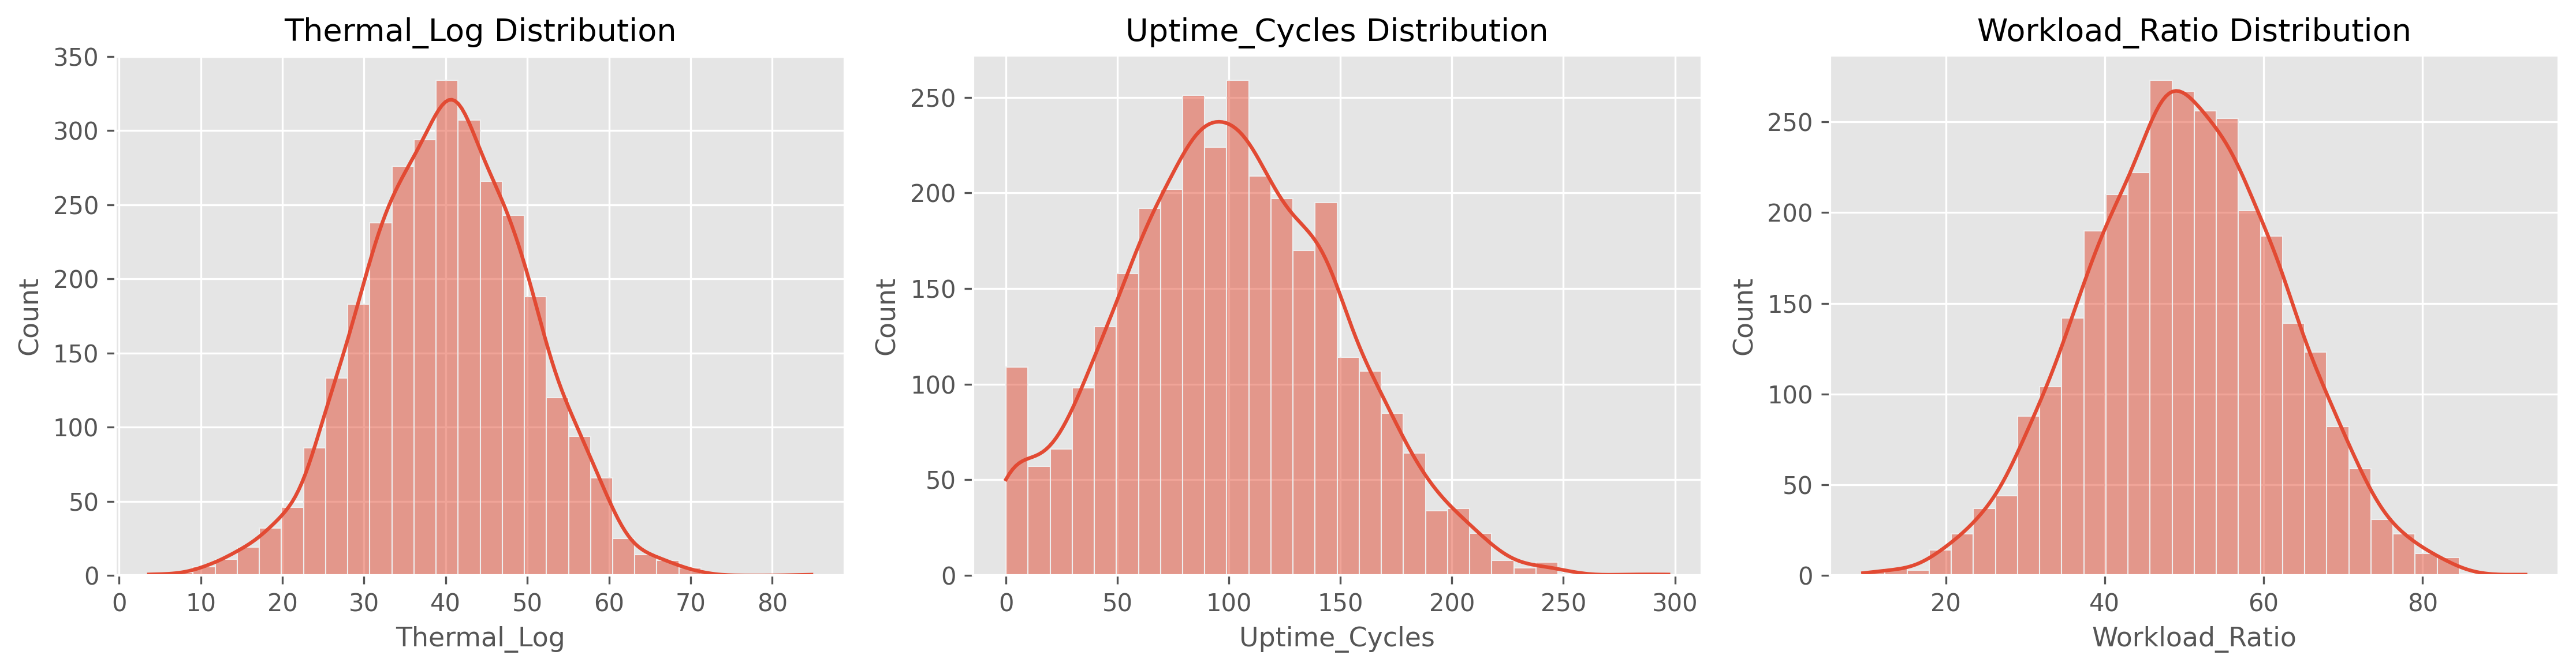

In [7]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df1_clean['Thermal_Log'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Thermal_Log Distribution')

sns.histplot(df1_clean['Uptime_Cycles'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Uptime_Cycles Distribution')

sns.histplot(df1_clean['Workload_Ratio'], bins=30, ax=axes[2], kde=True)
axes[2].set_title('Workload_Ratio Distribution')

plt.tight_layout()
plt.show()


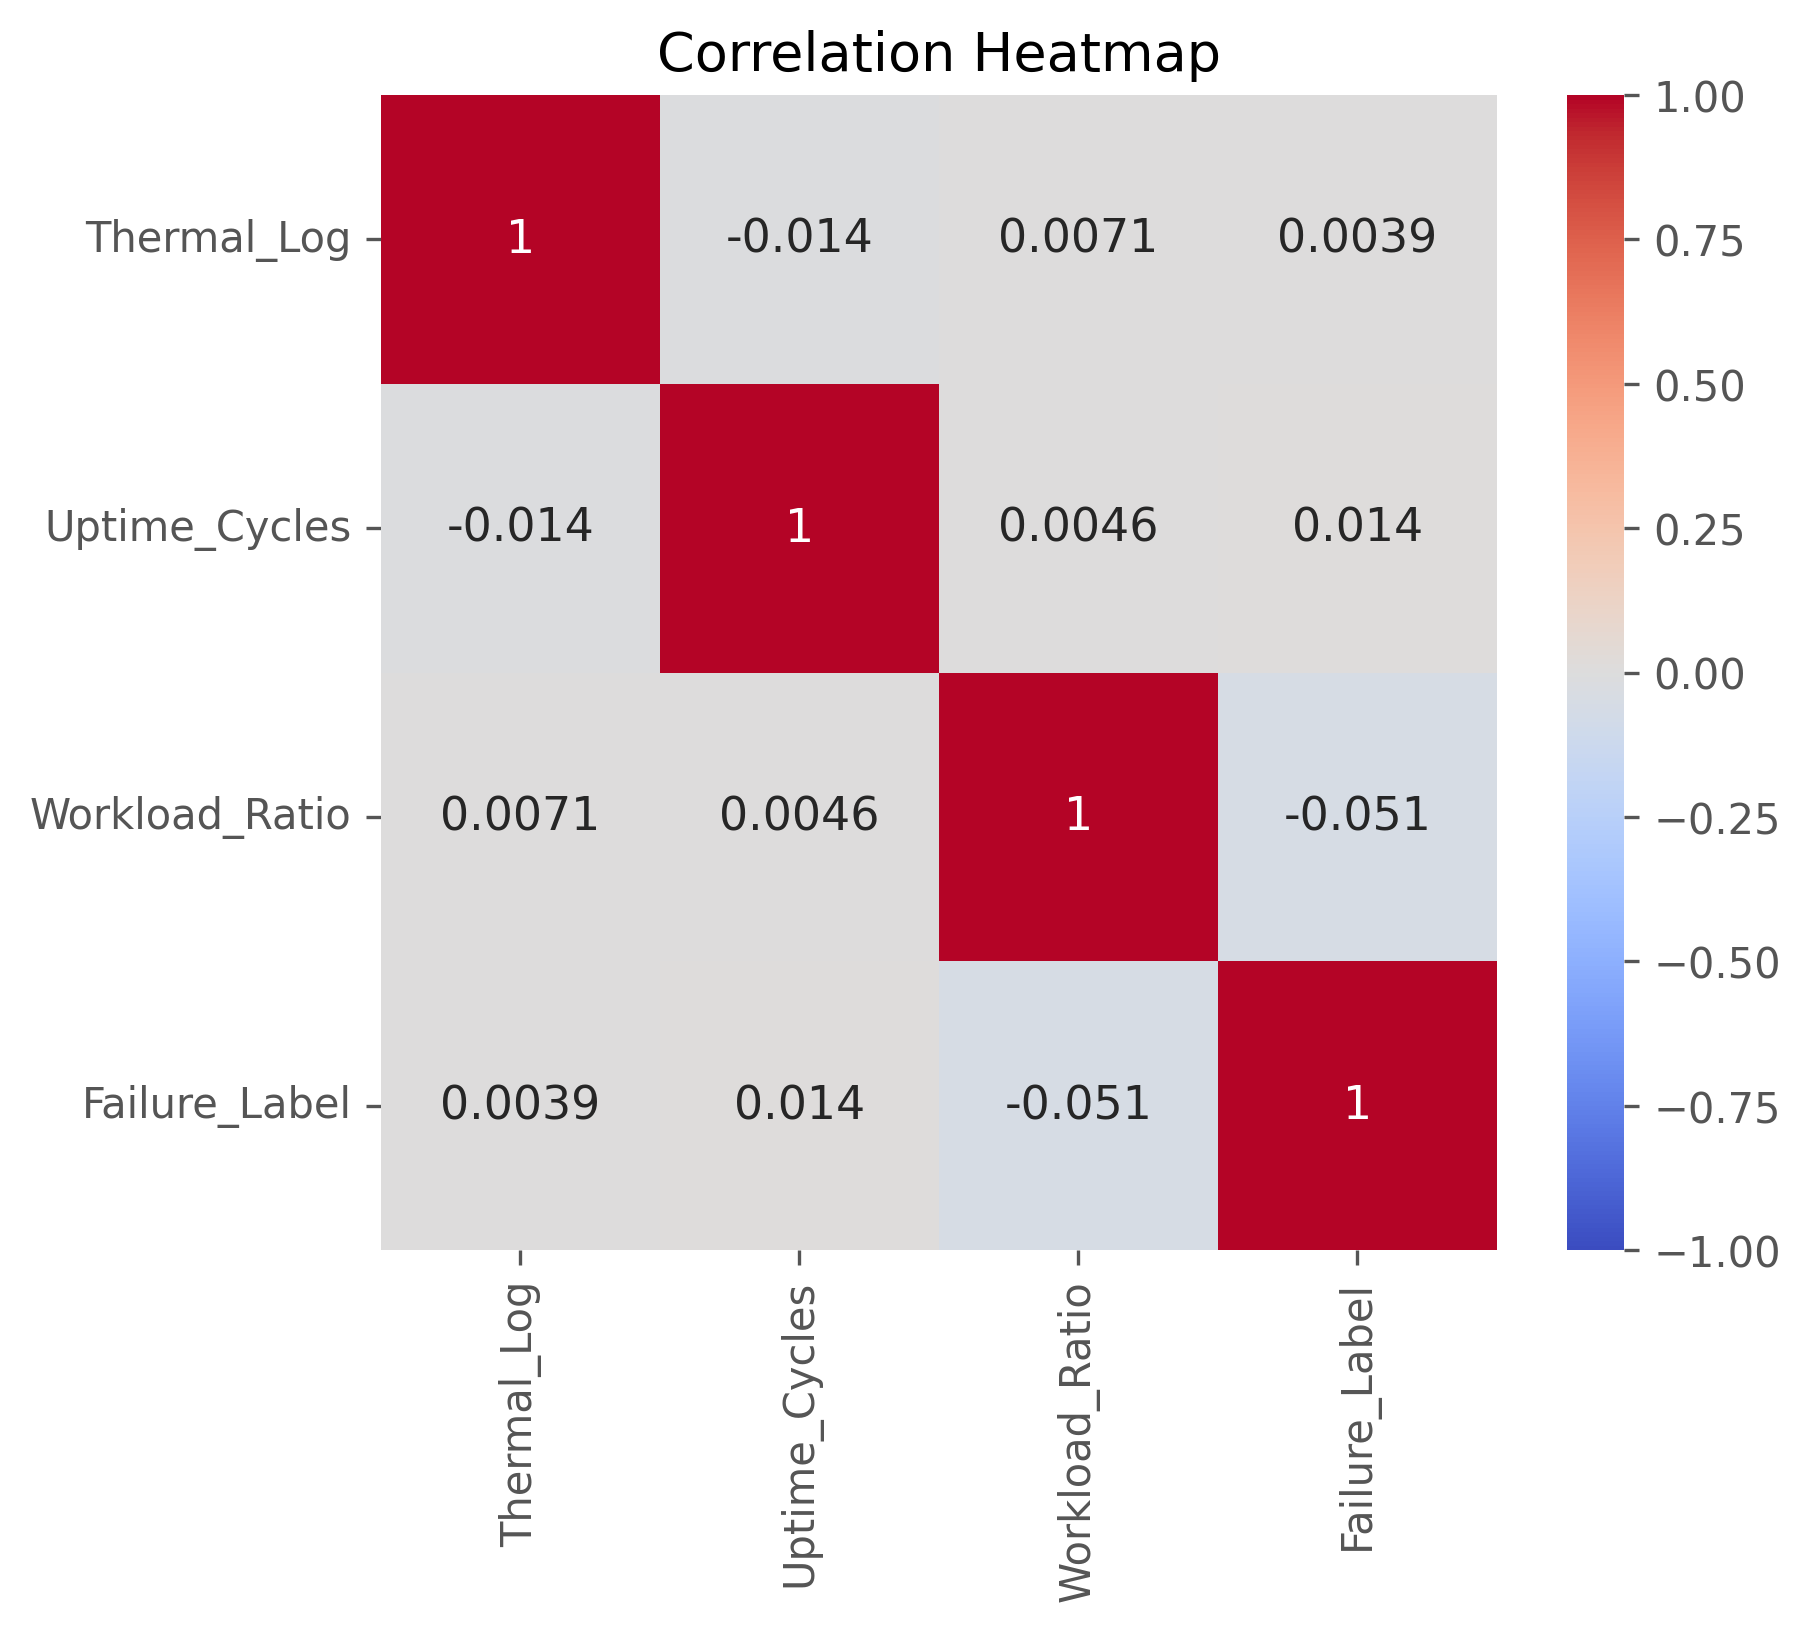

In [8]:
# Correlation heatmap
corr_cols = ['Thermal_Log', 'Uptime_Cycles', 'Workload_Ratio', 'Failure_Label']
corr = df1_clean[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


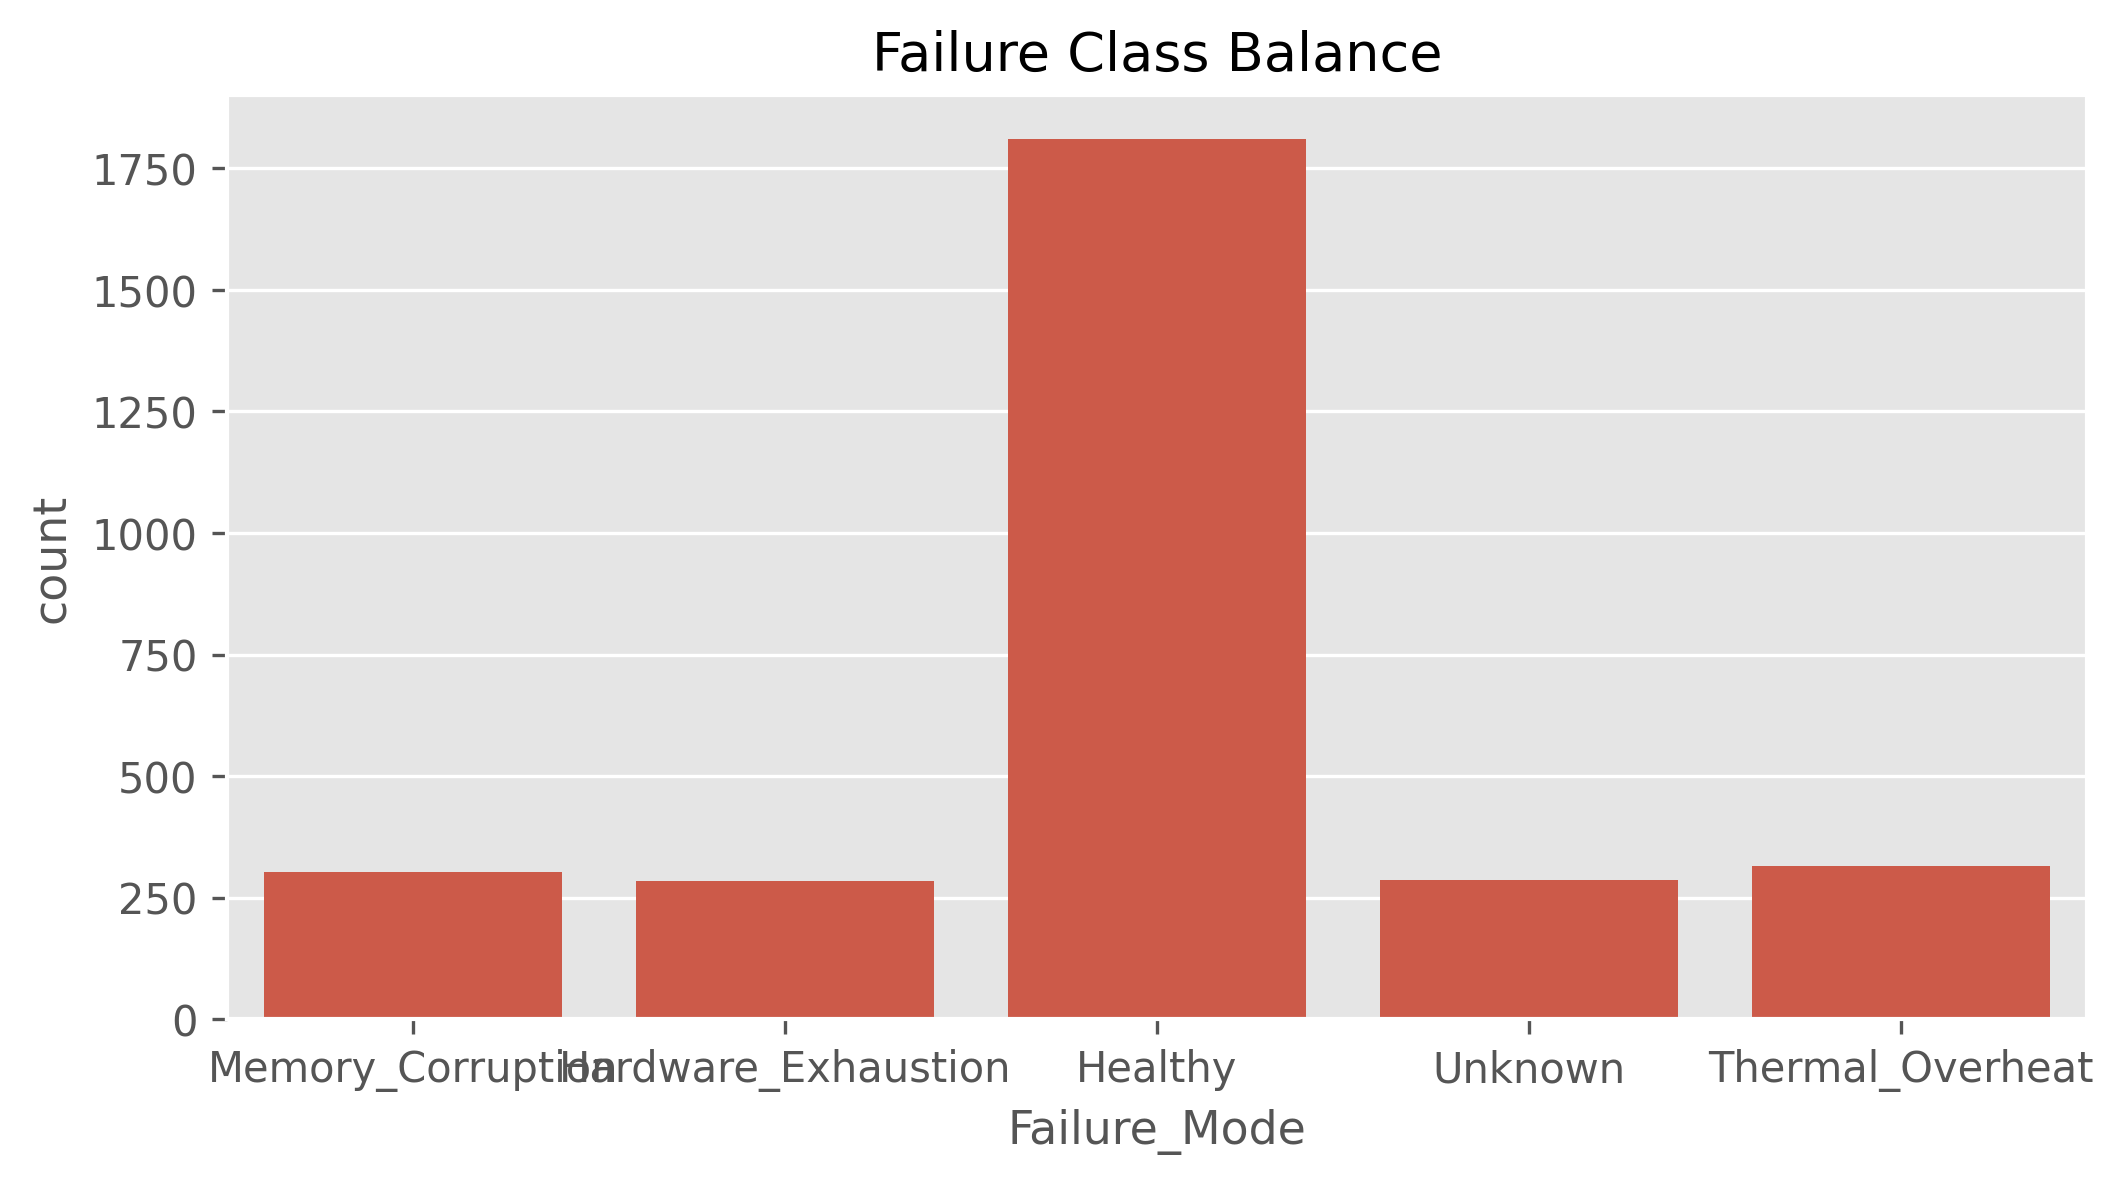

Failure Label Counts:
Failure_Mode
Healthy                60.333333
Thermal_Overheat       10.533333
Memory_Corruption      10.100000
Unknown                 9.533333
Hardware_Exhaustion     9.500000
Name: proportion, dtype: float64


In [9]:
# Failure class balance check
plt.figure(figsize=(8, 4))
sns.countplot(data=df1_clean, x='Failure_Mode')
plt.title('Failure Class Balance')
plt.show()

print("Failure Label Counts:")
print(df1_clean['Failure_Mode'].value_counts(normalize=True) * 100)
